In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))
train_images, test_images = train_images / 255.0, test_images / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9563 - loss: 0.1407 - val_accuracy: 0.9842 - val_loss: 0.0498
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9854 - loss: 0.0464 - val_accuracy: 0.9893 - val_loss: 0.0340
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 34ms/step - accuracy: 0.9895 - loss: 0.0341 - val_accuracy: 0.9873 - val_loss: 0.0395
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 31ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9899 - val_loss: 0.0316
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9858 - val_loss: 0.0489
313/313 - 4s - 13ms/step - accuracy: 0.9858 - loss: 0.0489
Test accuracy: 0.98580002784729


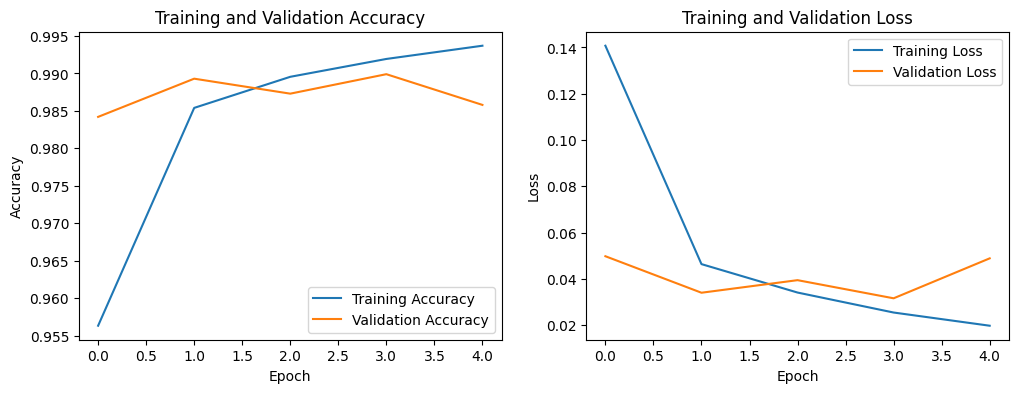

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [10]:
import numpy as np
index=0
prediction=model.predict(test_images[index:index+1])
prediction_digit = np.argmax(prediction)

print("Actual digit: ",test_labels[index])
print("Predicted digit: ",prediction_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Actual digit:  7
Predicted digit:  7


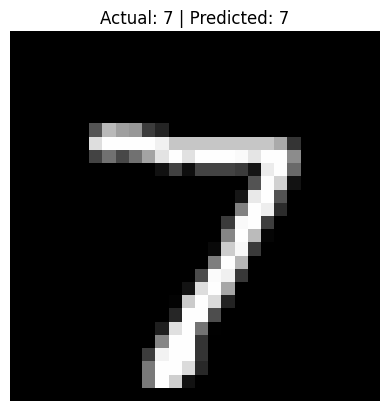

In [12]:
plt.imshow(test_images[index].reshape(28,28), cmap='gray')
plt.title("Actual: "+str(test_labels[index])+ " | Predicted: "+str(prediction_digit))
plt.axis('off')
plt.show()